# Wykład 3: Testy statystyczne

## 3.1 Od obserwacji do dowodu

W wykładzie 1 analizowaliśmy dane kliniczne pacjentów szpitala w Ankarze i zaobserwowaliśmy różnice między pacjentami z kamicą żółciową a grupą kontrolną. Pacjenci z kamicą mieli wyższy poziom CRP, niższy poziom witaminy D i wyższe BMI. Wykład zakończyliśmy stwierdzeniem, że potrzebujemy **testów statystycznych**, aby ocenić, czy te różnice są istotne.

Dziś odpowiemy na to pytanie. Wracamy do tych samych danych - ale tym razem dysponujemy narzędziami, które pozwolą odróżnić rzeczywisty efekt od przypadkowej fluktuacji.

### Hipoteza zerowa i wartość p

Idea testowania statystycznego opiera się na prostym rozumowaniu: **zakładamy, że różnicy nie ma** (hipoteza zerowa, $H_0$), i sprawdzamy, czy dane są z tym założeniem zgodne.

* **Hipoteza zerowa ($H_0$)** - różnica między grupami wynika z przypadku.
* **Hipoteza alternatywna ($H_1$)** - różnica jest rzeczywista.
* **Wartość p** (*p-value*) - prawdopodobieństwo zaobserwowania tak dużej (lub większej) różnicy, gdyby $H_0$ była prawdziwa.
* **Poziom istotności** - konwencjonalny próg $\alpha = 0{,}05$. Jeśli $p < \alpha$, odrzucamy $H_0$.

**Intuicja:** Wyobraźmy sobie świat, w którym zakładamy, że kamienie żółciowe nie mają żadnego związku z CRP, witaminą D ani BMI. Obie grupy pacjentów pochodzą z tej samej populacji, a zaobserwowane różnice wynikają wyłącznie z losowego doboru próby.

Sprawdzamy wtedy, jak prawdopodobne byłoby uzyskanie różnicy co najmniej tak dużej jak obserwowana w takim świecie. Jeśli to prawdopodobieństwo jest bardzo małe (np. 1 na 1000), uznajemy, że dane są bardzo niezgodne z założeniem o braku związku i mamy podstawy do odrzucenia hipotezy zerowej.

Inaczej mówiąc, jeśli wynik wygląda jak coś, co prawie nigdy nie zdarza się przy braku efektu, przestajemy traktować brak efektu jako wiarygodne wyjaśnienie danych.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/gallstone.csv')

# Usunięcie błędnych rekordów zidentyfikowanych w wykładzie 1
errors = [127, 178, 205, 239, 318]
df = df.drop(errors)

stone = df[df['Gallstone Status'] == 1]
control = df[df['Gallstone Status'] == 0]

print(f"Kamica:   {len(stone)} pacjentów")
print(f"Kontrola: {len(control)} pacjentów")

Kamica:   154 pacjentów
Kontrola: 160 pacjentów


## 3.2 Porównanie dwóch grup - zmienna ciągła

Zaczniemy od najprostszego scenariusza: mamy dwie grupy pacjentów (kamica vs. kontrola) i jedną zmienną ciągłą (np. CRP, witamina D, BMI). Chcemy sprawdzić, czy średnie w obu grupach różnią się istotnie. To klasyczne zastosowanie **testu t** lub jego nieparametrycznego odpowiednika — **testu Manna-Whitneya**. Ale zanim wybierzemy test, musimy sprawdzić, jakie założenia spełniają nasze dane.

### 3.2.1 Wizualizacja przed testem

Zanim uruchomimy jakikolwiek test, warto zobaczyć dane. Do porównania rozkładów w dwóch grupach doskonale nadaje się **wykres pudełkowy** (boxplot). W wykładzie 2 korzystaliśmy z wbudowanej metody `df.boxplot()` - teraz poznamy bibliotekę **seaborn**, która oferuje bardziej elastyczne wykresy statystyczne.

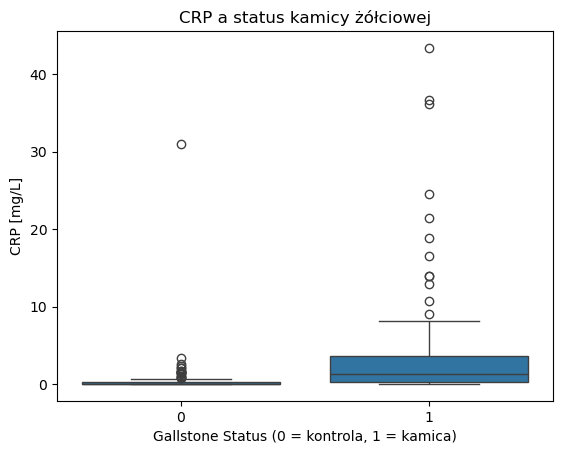

In [3]:
sns.boxplot(x='Gallstone Status', y='C-Reactive Protein (CRP)', data=df)
plt.title('CRP a status kamicy żółciowej')
plt.xlabel('Gallstone Status (0 = kontrola, 1 = kamica)')
plt.ylabel('CRP [mg/L]')
plt.show()

Wykres sugeruje wyraźną różnicę - mediana CRP w grupie z kamicą jest znacznie wyższa, a rozkład jest silnie prawoskośny (wiele wartości bliskich zeru, z długim ogonem wysokich wartości). Przyjrzyjmy się statystykom opisowym:

In [4]:
df.groupby('Gallstone Status')['C-Reactive Protein (CRP)'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Gallstone Status,,,,,,,,
0,160.0,0.47,2.49,0.0,0.0,0.0,0.31,31.0
1,154.0,3.33,6.40,0.0,0.2,1.3,3.58,43.4


Mediana CRP w grupie kontrolnej wynosi 0,00 mg/L (aż 94 ze 161 pacjentów ma CRP równe zero), podczas gdy w grupie z kamicą - 1,29 mg/L. Różnica średnich (0,46 vs 3,27) jest jeszcze większa, ale przy tak skośnych rozkładach mediana jest bardziej informatywna.

### 3.2.2 Sprawdzenie normalności rozkładu

Naszym celem jest porównanie średnich CRP między grupami. Klasycznym narzędziem do tego jest **test t-Studenta** — sprawdza on, czy różnica średnich dwóch grup jest większa niż moglibyśmy oczekiwać przez przypadek. Ma on jednak ważne założenie: dane w każdej grupie powinny mieć rozkład w przybliżeniu normalny. Jeśli to założenie nie jest spełnione, stosujemy test nieparametryczny, który nie wymaga normalności.

Do sprawdzenia normalności służy **test Shapiro-Wilka**. Jego hipoteza zerowa brzmi: „dane pochodzą z rozkładu normalnego."

Funkcja `stats.shapiro()` przyjmuje jako argument tablicę wartości liczbowych (tu: kolumnę CRP jednej grupy) i zwraca dwie wartości:

- **statystykę testową** — liczbę, która podsumowuje, jak bardzo dane odbiegają od rozkładu normalnego. Każdy test statystyczny wylicza swoją statystykę według określonego wzoru; nie musimy znać szczegółów — ważne jest, że im bliżej 1, tym lepsze dopasowanie do normalności (dla testu Shapiro-Wilka),
- **wartość p** — już nam znana. Tu odpowiada na pytanie: „gdyby dane rzeczywiście pochodziły z rozkładu normalnego, jak prawdopodobne byłoby zaobserwowanie aż tak dużego odchylenia od normalności?"

Ten wzorzec — funkcja zwracająca parę `(statystyka, p)` — powtarza się w niemal wszystkich testach z `scipy.stats`.

In [5]:
stat, p = stats.shapiro(control['C-Reactive Protein (CRP)'])
print(f"Shapiro-Wilk (kontrola): statystyka = {stat:.4f}, p = {p:.2e}")

Shapiro-Wilk (kontrola): statystyka = 0.1449, p = 1.66e-26


In [6]:
stat, p = stats.shapiro(stone['C-Reactive Protein (CRP)'])
print(f"Shapiro-Wilk (kamica):   statystyka = {stat:.4f}, p = {p:.2e}")

Shapiro-Wilk (kamica):   statystyka = 0.5144, p = 1.63e-20


W obu grupach wartość p jest skrajnie mała (rzędu $10^{-26}$ i $10^{-21}$) - normalność jest zdecydowanie odrzucona. Nie powinno to dziwić: CRP ma rozkład silnie prawoskośny, z masą obserwacji przy zerze i długim ogonem. Histogram to potwierdza:

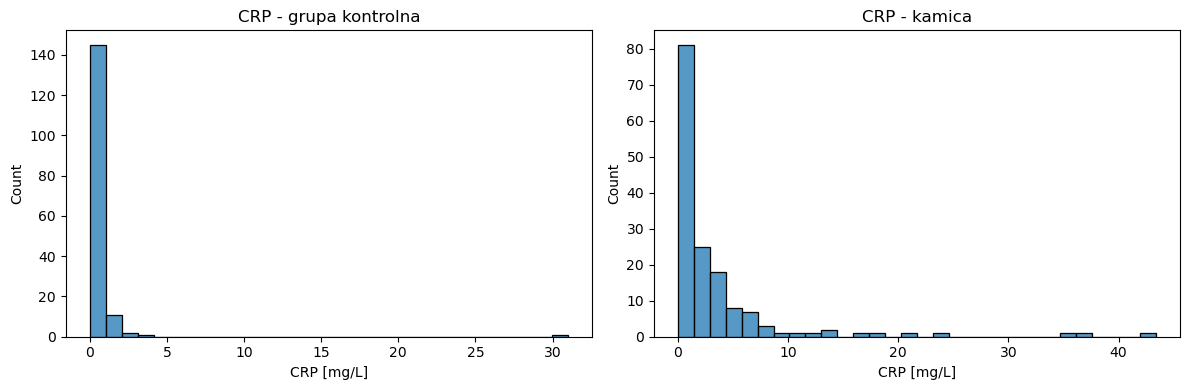

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(control['C-Reactive Protein (CRP)'], bins=30, ax=axes[0])
axes[0].set_title('CRP - grupa kontrolna')
axes[0].set_xlabel('CRP [mg/L]')

sns.histplot(stone['C-Reactive Protein (CRP)'], bins=30, ax=axes[1])
axes[1].set_title('CRP - kamica')
axes[1].set_xlabel('CRP [mg/L]')

plt.tight_layout()
plt.show()

### 3.2.3 Test Manna-Whitneya

Skoro rozkłady nie są normalne, stosujemy **test Manna-Whitneya** (zwany też testem U) — nieparametryczną alternatywę dla testu t-Studenta. Test ten nie porównuje średnich, lecz sprawdza, czy wartości w jednej grupie mają tendencję do bycia większymi niż w drugiej. Nie wymaga założenia o normalności rozkładu. 

Formalnie hipoteza zerowa tego testu mówi, że rozkłady w obu grupach są identyczne. W praktyce, gdy kształty rozkładów są podobne (co widzieliśmy na histogramach — oba są prawoskośne), odrzucenie H₀ możemy interpretować jako różnicę w położeniu (mediany), czyli że wartości w jednej grupie są systematycznie wyższe niż w drugiej.

Funkcja `stats.mannwhitneyu()` przyjmuje jako dwa pierwsze argumenty tablice wartości z porównywanych grup. Trzeci argument, `alternative`, określa rodzaj hipotezy alternatywnej:

- `'two-sided'` (domyślny) — testujemy, czy grupy się różnią, bez zakładania kierunku różnicy. Wykryjemy zarówno sytuację, w której grupa A ma wyższe wartości niż B, jak i odwrotną.
- `'greater'` — testujemy, czy pierwsza grupa ma wyższe wartości.
- `'less'` — testujemy, czy pierwsza grupa ma niższe wartości.

W badaniach eksploracyjnych, gdy nie mamy silnych a priori oczekiwań co do kierunku różnicy, stosujemy test dwustronny (`'two-sided'`). Parametr `alternative` spotkamy też w innych testach z `scipy.stats` — działa wszędzie tak samo.

In [8]:
stat, p = stats.mannwhitneyu(stone['C-Reactive Protein (CRP)'],
                              control['C-Reactive Protein (CRP)'],
                              alternative='two-sided')
print(f"Mann-Whitney U: statystyka = {stat:.1f}, p = {p:.2e}")

Mann-Whitney U: statystyka = 19586.0, p = 1.26e-20


Wartość $p = 1{,}26 \times 10^{-20}$ jest astronomicznie mała. Różnica poziomów CRP między grupami jest **wysoce istotna statystycznie**. Pacjenci z kamicą żółciową mają istotnie wyższe stężenie białka C-reaktywnego, co jest spójne z rolą stanu zapalnego w patogenezie tej choroby.

### 3.2.4 Powtórzenie procedury - witamina D

Zastosujmy ten sam schemat do drugiej zmiennej, która różniła się w wykładzie 1.

**Wizualizacja:**

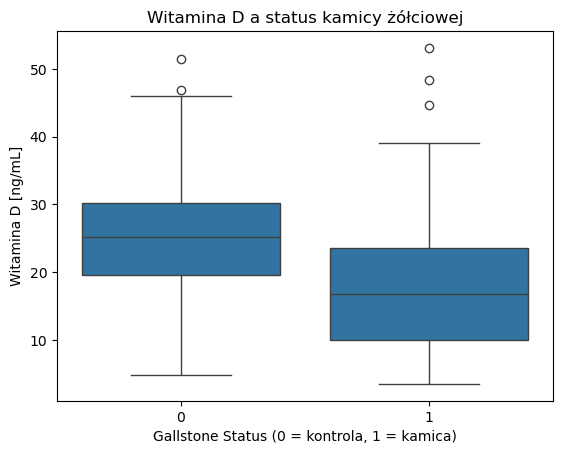

In [9]:
sns.boxplot(x='Gallstone Status', y='Vitamin D', data=df)
plt.title('Witamina D a status kamicy żółciowej')
plt.xlabel('Gallstone Status (0 = kontrola, 1 = kamica)')
plt.ylabel('Witamina D [ng/mL]')
plt.show()

In [10]:
df.groupby('Gallstone Status')['Vitamin D'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Gallstone Status,,,,,,,,
0,160.0,24.89,9.14,4.8,19.54,25.24,30.22,51.4
1,154.0,17.73,9.56,3.5,9.95,16.75,23.52,53.1


Mediana witaminy D w grupie kontrolnej (25,24 ng/mL) jest wyraźnie wyższa niż w grupie z kamicą (16,75 ng/mL). Rozkład wygląda bardziej symetrycznie niż CRP - sprawdźmy formalnie:

**Normalność:**

In [11]:
stat, p = stats.shapiro(control['Vitamin D'])
print(f"Shapiro-Wilk (kontrola): p = {p:.4f}")

stat, p = stats.shapiro(stone['Vitamin D'])
print(f"Shapiro-Wilk (kamica):   p = {p:.2e}")

Shapiro-Wilk (kontrola): p = 0.0242
Shapiro-Wilk (kamica):   p = 9.40e-06


Normalność odrzucona w obu grupach, choć wartości p są znacznie mniej ekstremalne niż dla CRP. W grupie kontrolnej $p = 0{,}024$ - to odrzucenie przy $\alpha = 0{,}05$, ale stosunkowo bliskie granicy. W praktyce badań biomedycznych, gdy Shapiro odrzuca normalność, bezpieczniej jest stosować test nieparametryczny.

**Test Manna-Whitneya:**

In [12]:
stat, p = stats.mannwhitneyu(stone['Vitamin D'],
                              control['Vitamin D'],
                              alternative='two-sided')
print(f"Mann-Whitney U: statystyka = {stat:.1f}, p = {p:.2e}")

Mann-Whitney U: statystyka = 6840.0, p = 9.53e-12


Wynik jest jednoznaczny: $p = 9{,}53 \times 10^{-12}$. Pacjenci z kamicą żółciową mają istotnie niższy poziom witaminy D.

### 3.2.5 Schemat decyzyjny

Procedura, którą właśnie dwukrotnie zastosowaliśmy, ma stałą strukturę:

1. **Wizualizacja** - `sns.boxplot()` do porównania rozkładów.
2. **Test normalności** - `stats.shapiro()` osobno dla każdej grupy.
3. **Wybór testu:**
   * Obie grupy normalne - `stats.ttest_ind()` (test t-Studenta, wariant Welcha z `equal_var=False`).
   * Którakolwiek grupa nienormalna - `stats.mannwhitneyu()` (test Manna-Whitneya).
4. **Interpretacja** - porównanie wartości p z progiem $\alpha = 0{,}05$.

> **Uwaga:** Test t-Studenta jest odporny na umiarkowane odchylenia od normalności przy dużych próbach. W praktyce badań biologicznych jednak wiele zmiennych (stężenia białek, markery zapalne, koszty leczenia) ma rozkłady silnie skośne i test Manna-Whitneya jest stosowany znacznie częściej.

## 3.3 Porównanie dwóch grup - zmienna kategoryczna

### 3.3.1 Pytanie: czy płeć jest czynnikiem ryzyka?

Dotychczas porównywaliśmy zmienne ciągłe (CRP, witamina D) między grupami. Ale w danych mamy też zmienne kategoryczne. Jednym z klasycznych pytań w epidemiologii kamicy żółciowej jest rola płci - w literaturze medycznej kamica częściej występuje u kobiet.

W naszym zbiorze płeć jest zakodowana binarnie: `Gender = 0` oznacza mężczyznę, `Gender = 1` - kobietę (co można zweryfikować porównując średni wzrost i wagę w obu grupach).

Zaczynamy od tabeli kontyngencji, którą poznaliśmy w wykładzie 1:

In [13]:
ct = pd.crosstab(df['Gender'], df['Gallstone Status'], margins=True)
ct

Gallstone Status,0,1,All
Gender,,,
0,94,67,161
1,66,87,153
All,160,154,314


Parametr `margins=True` dodaje wiersz i kolumnę z sumami. Widzimy, że wśród mężczyzn (Gender = 0) kamica występuje u 67 ze 161 (42%), a wśród kobiet (Gender = 1) - u 87 ze 153 (57%). Różnica jest widoczna, ale czy jest istotna?

**Wizualizacja:**

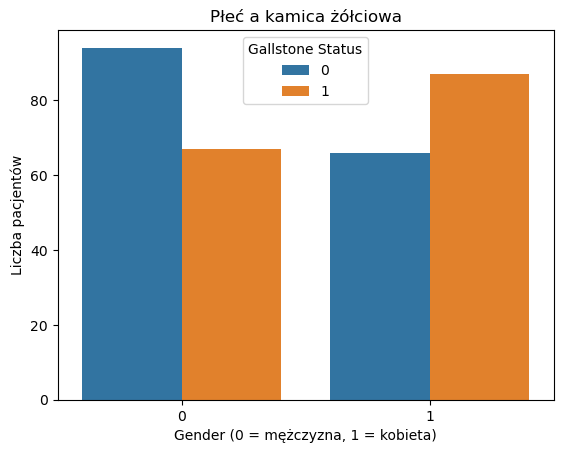

In [14]:
sns.countplot(x='Gender', hue='Gallstone Status', data=df)
plt.title('Płeć a kamica żółciowa')
plt.xlabel('Gender (0 = mężczyzna, 1 = kobieta)')
plt.ylabel('Liczba pacjentów')
plt.legend(title='Gallstone Status')
plt.show()

### 3.3.2 Test chi-kwadrat ($\chi^2$)

Do testowania niezależności dwóch zmiennych kategorycznych służy **test chi-kwadrat**. Jego logika jest intuicyjna:

1. Obliczamy **częstości oczekiwane** - ile pacjentów byłoby w każdej komórce tabeli, gdyby płeć i kamica były niezależne.
2. Porównujemy je z częstościami **obserwowanymi**.
3. Im większa rozbieżność, tym silniejszy dowód przeciw niezależności.

In [15]:
chi2, p, dof, expected = stats.chi2_contingency(ct.iloc[:-1, :-1])

print(f"Statystyka chi-kwadrat: {chi2:.4f}")
print(f"Wartość p:              {p:.4f}")
print(f"Stopnie swobody:        {dof}")

Statystyka chi-kwadrat: 6.7009
Wartość p:              0.0096
Stopnie swobody:        1


Funkcja `chi2_contingency()` przyjmuje tabelę kontyngencji **bez marginesów** - dlatego stosujemy `ct.iloc[:-1, :-1]`, aby odciąć wiersz i kolumnę z sumami.

> **Uwaga techniczna:** `iloc[:-1, :-1]` to indeksowanie pozycyjne poznane w wykładzie 1. Zapis `:-1` oznacza „wszystko oprócz ostatniego elementu".

Funkcja zwraca cztery wartości:

* `chi2` - statystyka testowa,
* `p` - wartość p,
* `dof` - liczbę stopni swobody,
* `expected` - tablicę częstości oczekiwanych.

**Częstości oczekiwane** możemy obejrzeć, umieszczając je w ramce danych:

In [16]:
pd.DataFrame(expected.round(1),
             index=['Mężczyźni', 'Kobiety'],
             columns=['Kontrola', 'Kamica'])

,Kontrola,Kamica
Mężczyźni,82.0,79.0
Kobiety,78.0,75.0


Gdyby płeć nie miała związku z kamicą, oczekiwalibyśmy około 82 zdrowych mężczyzn - a obserwujemy 94. W drugą stronę, oczekiwalibyśmy 75 kobiet z kamicą, a obserwujemy 87. Te rozbieżności, zsumowane i znormalizowane, dają statystykę $\chi^2 = 6{,}70$.

Wartość $p = 0{,}0096 < 0{,}05$ — odrzucamy hipotezę zerową o niezależności płci i kamicy żółciowej. **Związek między płcią a kamicą jest istotny statystycznie.**

Sam test chi-kwadrat mówi nam jedynie, że związek istnieje — nie wskazuje jego kierunku. Kierunek odczytujemy z porównania częstości obserwowanych z oczekiwanymi: wśród mężczyzn kamicę ma 67 osób, podczas gdy przy braku związku oczekiwalibyśmy 79 — jest ich zatem *mniej* niż gdyby płeć nie miała znaczenia. U kobiet sytuacja jest odwrotna: obserwujemy 87 przypadków kamicy wobec oczekiwanych 75. Test sugeruje, że te rozbieżności nie są dziełem przypadku.

## 3.4 Korelacja

### 3.4.1 Pytanie: czy dwie zmienne ciągłe są ze sobą powiązane?

Dotychczas porównywaliśmy jedną zmienną między dwoma grupami. Teraz zadamy inne pytanie: **czy dwie zmienne zmieniają się razem?** Na przykład - czy pacjenci z wyższym BMI mają też wyższy poziom glukozy?

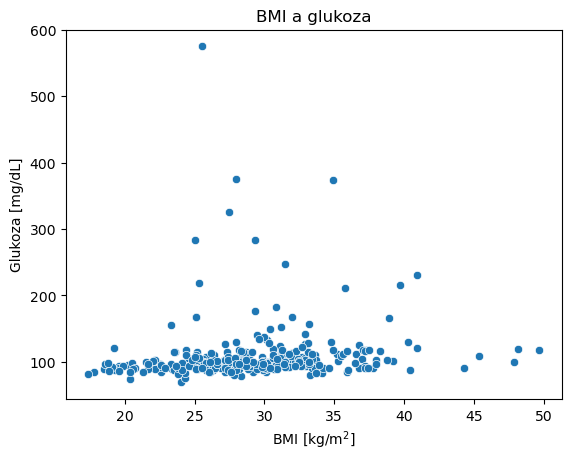

In [17]:
sns.scatterplot(x='Body Mass Index (BMI)', y='Glucose', data=df)
plt.title('BMI a glukoza')
plt.xlabel('BMI [kg/m$^2$]')
plt.ylabel('Glukoza [mg/dL]')
plt.show()

Wykres punktowy sugeruje pewien trend wzrostowy, ale z dużym rozproszeniem. Aby opisać siłę i kierunek zależności liczbowo, obliczamy **współczynnik korelacji**.

### 3.4.2 Korelacja Pearsona i Spearmana

Biblioteka `scipy.stats` oferuje dwa współczynniki korelacji:

* **Korelacja Pearsona** ($r$) - mierzy siłę zależności **liniowej**. Zakłada, że obie zmienne mają rozkład w przybliżeniu normalny.
* **Korelacja Spearmana** ($\rho$) - mierzy siłę zależności **monotonicznej** (niekoniecznie liniowej). Działa na rangach, nie wymaga normalności.

Obie funkcje zwracają dwie wartości: współczynnik korelacji i wartość p testującą hipotezę „korelacja wynosi zero" ($H_0\colon \rho = 0$).

In [18]:
r, p = stats.pearsonr(df['Body Mass Index (BMI)'], df['Glucose'])
print(f"Pearson:  r = {r:.4f}, p = {p:.4f}")

Pearson:  r = 0.1245, p = 0.0274


In [19]:
rho, p = stats.spearmanr(df['Body Mass Index (BMI)'], df['Glucose'])
print(f"Spearman: ρ = {rho:.4f}, p = {p:.2e}")

Spearman: ρ = 0.3322, p = 1.59e-09


Różnica między wynikami jest pouczająca. Korelacja Pearsona ($r = 0{,}12$) jest słaba, a Spearmana ($\rho = 0{,}33$) - umiarkowana. Oznacza to, że zależność BMI – glukoza istnieje, ale nie jest liniowa - Spearman, działając na rangach, lepiej ją wychwytuje. W danych biomedycznych, gdzie rozkłady często odbiegają od normalności, **korelacja Spearmana jest zwykle bezpieczniejszym wyborem**.

### 3.4.3 Drugi przykład - CRP a witamina D

Zbadajmy zależność między dwoma zmiennymi, które okazały się istotne w porównaniach międzygrupowych:

In [20]:
rho, p = stats.spearmanr(df['C-Reactive Protein (CRP)'], df['Vitamin D'])
print(f"Spearman: ρ = {rho:.4f}, p = {p:.2e}")

Spearman: ρ = -0.2377, p = 2.08e-05


Korelacja jest ujemna ($\rho = -0{,}24$): pacjenci z wyższym CRP mają tendencję do niższego poziomu witaminy D. Jest to biologicznie sensowne - stan zapalny i niedobór witaminy D często współwystępują. Wartość $p = 2{,}1 \times 10^{-5}$ sugeruje, że ta zależność nie jest przypadkowa.

### 3.4.4 Macierz korelacji i heatmapa

Gdy interesuje nas wiele zmiennych jednocześnie, obliczanie korelacji parami staje się żmudne. Metoda `corr()` ramki danych oblicza macierz korelacji dla wszystkich kolumn numerycznych naraz:

In [21]:
cols = ['Age', 'Body Mass Index (BMI)', 'Glucose', 'Total Cholesterol (TC)',
        'Triglyceride', 'C-Reactive Protein (CRP)', 'Vitamin D', 'Hemoglobin (HGB)']

corr_matrix = df[cols].corr(method='spearman').round(2)
corr_matrix

,Age,Body Mass Index (BMI),Glucose,Total Cholesterol (TC),Triglyceride,C-Reactive Protein (CRP),Vitamin D,Hemoglobin (HGB)
Age,1.00,0.25,0.40,0.16,0.12,0.12,0.04,-0.12
Body Mass Index (BMI),0.25,1.00,0.33,0.01,0.24,0.24,-0.09,-0.06
Glucose,0.40,0.33,1.00,0.07,0.20,0.02,0.10,0.04
Total Cholesterol (TC),0.16,0.01,0.07,1.00,0.41,-0.02,-0.01,0.11
Triglyceride,0.12,0.24,0.20,0.41,1.00,-0.00,-0.08,0.33
C-Reactive Protein (CRP),0.12,0.24,0.02,-0.02,-0.00,1.00,-0.24,-0.12
Vitamin D,0.04,-0.09,0.10,-0.01,-0.08,-0.24,1.00,0.03
Hemoglobin (HGB),-0.12,-0.06,0.04,0.11,0.33,-0.12,0.03,1.00


Argument `method='spearman'` w metodzie `corr()` powoduje obliczenie korelacji rang Spearmana. Domyślnie pandas oblicza korelację Pearsona.

Tabela 8×8 jest trudna do szybkiego odczytania. **Heatmapa** (mapa cieplna) zamienia liczby na kolory:

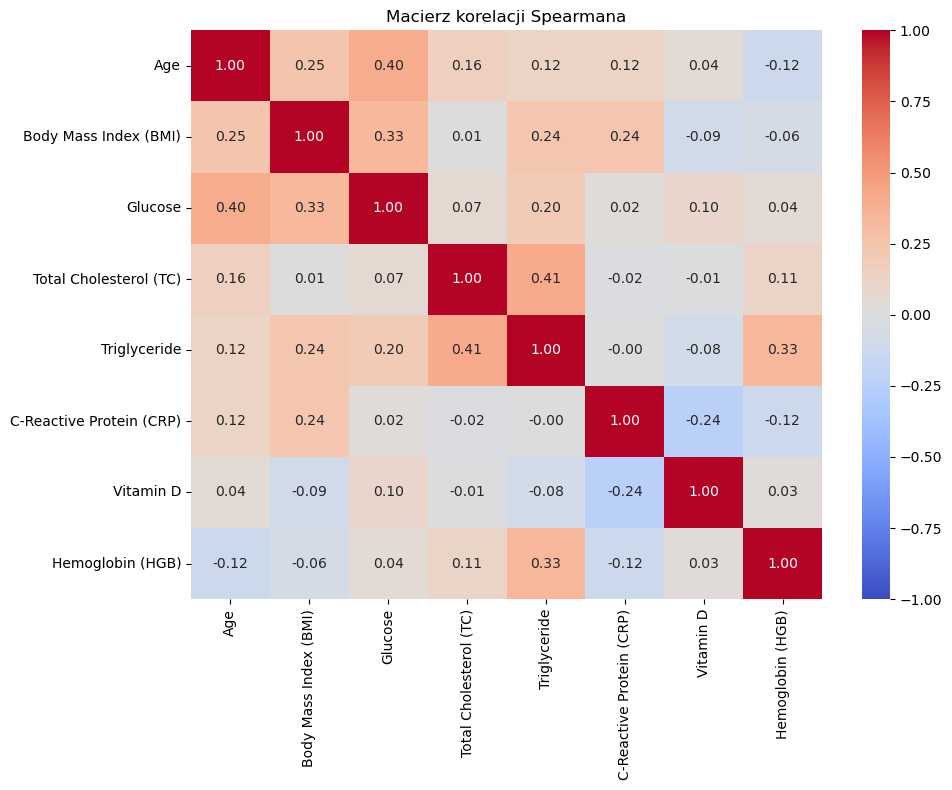

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, fmt='.2f')
plt.title('Macierz korelacji Spearmana')
plt.tight_layout()
plt.show()

Parametry `sns.heatmap()`:

* `annot=True` - wyświetla wartości liczbowe w komórkach,
* `cmap='coolwarm'` - skala kolorów od niebieskiego (korelacja ujemna) przez biały (brak) do czerwonego (korelacja dodatnia),
* `center=0` - punkt neutralny skali kolorów na zero,
* `vmin=-1, vmax=1` - zakres osi kolorów odpowiadający zakresowi współczynnika korelacji.

Na heatmapie widać kilka wzorców. Najsilniejsze korelacje to: wiek-glukoza ($\rho = 0{,}40$), cholesterol-trójglicerydy ($\rho = 0{,}39$), BMI-glukoza ($\rho = 0{,}33$) i trójglicerydy-hemoglobina ($\rho = 0{,}33$). CRP jest ujemnie skorelowane z witaminą D ($\rho = -0{,}24$), co potwierdziliśmy wcześniej testem.

## 3.5 Problem wielokrotnych porównań

W naszych danych mamy dziesiątki zmiennych numerycznych. Gdybyśmy przetestowali każdą z nich testem Manna-Whitneya, otrzymalibyśmy wiele wartości p. Zobaczmy:

In [23]:
numeric_cols = ['Age', 'Body Mass Index (BMI)', 'Glucose',
                'Total Cholesterol (TC)', 'Triglyceride',
                'C-Reactive Protein (CRP)', 'Vitamin D',
                'Hemoglobin (HGB)', 'Visceral Fat Area (VFA)',
                'Total Body Fat Ratio (TBFR) (%)']

results = []
for col in numeric_cols:
    stat, p = stats.mannwhitneyu(stone[col], control[col], alternative='two-sided')
    results.append({'Zmienna': col, 'p-value': p})

results_df = pd.DataFrame(results).sort_values('p-value')
results_df['Istotne (α=0.05)'] = results_df['p-value'] < 0.05
results_df

,Zmienna,p-value,Istotne (α=0.05)
5,C-Reactive Protein (CRP),1.259822e-20,True
6,Vitamin D,9.533795e-12,True
9,Total Body Fat Ratio (TBFR) (%),6.314699e-05,True
7,Hemoglobin (HGB),4.516996e-04,True
8,Visceral Fat Area (VFA),4.726568e-03,True
1,Body Mass Index (BMI),3.527450e-02,True
2,Glucose,2.495843e-01,False
0,Age,4.728754e-01,False
4,Triglyceride,7.132910e-01,False
3,Total Cholesterol (TC),7.653712e-01,False


Przy 100 niezależnych testach i progu $\alpha = 0{,}05$ prawdopodobieństwo, że *co najmniej jeden* z nich da fałszywie istotny wynik — nawet gdy żadna rzeczywista różnica nie istnieje — wynosi $1 - (1 - 0{,}05)^{100} \approx 99{,}4\%$. Mamy tu tylko 10 zmiennych, ale w badaniach genomicznych czy proteomicznych testuje się tysiące zmiennych jednocześnie — bez korekty wyniki byłyby zdominowane przez fałszywe odkrycia.

Najprostsza korekta to **metoda Bonferroniego**: dzielimy próg istotności przez liczbę przeprowadzonych testów. Przy 10 testach skorygowany próg wynosi $\alpha / 10 = 0{,}005$.

In [24]:
n_tests = len(numeric_cols)
results_df['Istotne (Bonferroni)'] = results_df['p-value'] < 0.05 / n_tests
results_df

,Zmienna,p-value,Istotne (α=0.05),Istotne (Bonferroni)
5,C-Reactive Protein (CRP),1.259822e-20,True,True
6,Vitamin D,9.533795e-12,True,True
9,Total Body Fat Ratio (TBFR) (%),6.314699e-05,True,True
7,Hemoglobin (HGB),4.516996e-04,True,True
8,Visceral Fat Area (VFA),4.726568e-03,True,True
1,Body Mass Index (BMI),3.527450e-02,True,False
2,Glucose,2.495843e-01,False,False
0,Age,4.728754e-01,False,False
4,Triglyceride,7.132910e-01,False,False
3,Total Cholesterol (TC),7.653712e-01,False,False


Po korekcie Bonferroniego jedna zmienna (BMI), która wcześniej była istotna, traci istotność - jej wartość p ($0{,}035$) nie przechodzi surowszego progu. Zmienne o najsilniejszych efektach (CRP, witamina D, TBFR, hemoglobina, VFA) pozostają nadal istotne.

Wniosek praktyczny: **gdy przeprowadzamy wiele testów, powinniśmy albo korygować próg istotności, albo traktować wyniki graniczne z ostrożnością.** Korekta Bonferroniego jest konserwatywna (surowa), ale prosta i powszechnie akceptowana w publikacjach biomedycznych.

## 3.6 Podsumowanie

### Odpowiedź na pytanie badawcze

Testy statystyczne potwierdziły obserwacje eksploracyjne z wykładu 1:

* **CRP** - istotnie wyższe w grupie z kamicą ($p = 1{,}26 \times 10^{-20}$, test Manna-Whitneya). Jest to najsilniejsza z zaobserwowanych różnic.
* **Witamina D** - istotnie niższa w grupie z kamicą ($p = 9{,}53 \times 10^{-12}$).
* **Płeć** - kobiety mają istotnie wyższe ryzyko kamicy ($p = 0{,}010$, test $\chi^2$).
* **BMI i glukoza** - umiarkowanie skorelowane ($\rho = 0{,}33$), co sugeruje związek między otyłością a zaburzeniami metabolicznymi.
* **CRP i witamina D** - ujemnie skorelowane ($\rho = -0{,}24$), co jest spójne z biologicznym powiązaniem stanu zapalnego i niedoboru witaminy D.

Nie wszystkie zmienne okazały się istotne — jak pokazała analiza wielokrotnych porównań w sekcji 3.5, wiek, cholesterol całkowity, trójglicerydy i glukoza nie różnią się istotnie między grupami.

### Nowe narzędzia

| Kategoria | Funkcje |
|-----------|---------|
| Normalność | `stats.shapiro()` |
| Porównanie dwóch grup (ciągła) | `stats.ttest_ind()`, `stats.mannwhitneyu()` |
| Niezależność zmiennych kategorycznych | `stats.chi2_contingency()` |
| Korelacja | `stats.pearsonr()`, `stats.spearmanr()`, `df.corr()` |
| Wizualizacja (seaborn) | `sns.boxplot()`, `sns.histplot()`, `sns.countplot()`, `sns.scatterplot()`, `sns.heatmap()` |

### Co dalej

Wiemy już, **które** zmienne różnią się między grupami i **które** ze sobą korelują. Dotychczas pracowaliśmy wyłącznie z danymi tabelarycznymi — wiersze to pacjenci, kolumny to zmienne. W następnym wykładzie wyjdziemy poza tabele: poznamy bibliotekę NumPy i jej wielowymiarowe tablice, analizując dane z mikroskopii fluorescencyjnej — time-lapse podziału komórkowego zarejestrowany w pięciu wymiarach.